In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf

In [46]:
df = pd.read_csv("econ-gen-pib-composante-trim.csv", sep="\t")

df = df.drop(columns=["Unnamed: 2"])

df["Produit intérieur brut (PIB)"] = (
    df["Produit intérieur brut (PIB)"]
        .str.replace(",", ".", regex=False)
        .astype(float)
)

df["Trimestre"] = pd.PeriodIndex(df["Trimestre"], freq="Q")
df = df.iloc[::-1].reset_index(drop=True)

dates = df["Trimestre"]
series = df["Produit intérieur brut (PIB)"]

df.head()

,Trimestre,Produit intérieur brut (PIB)
0,1949Q1,0.9
1,1949Q1,1.5
2,1949Q2,1.4
3,1950Q1,2.7
4,1950Q1,2.5


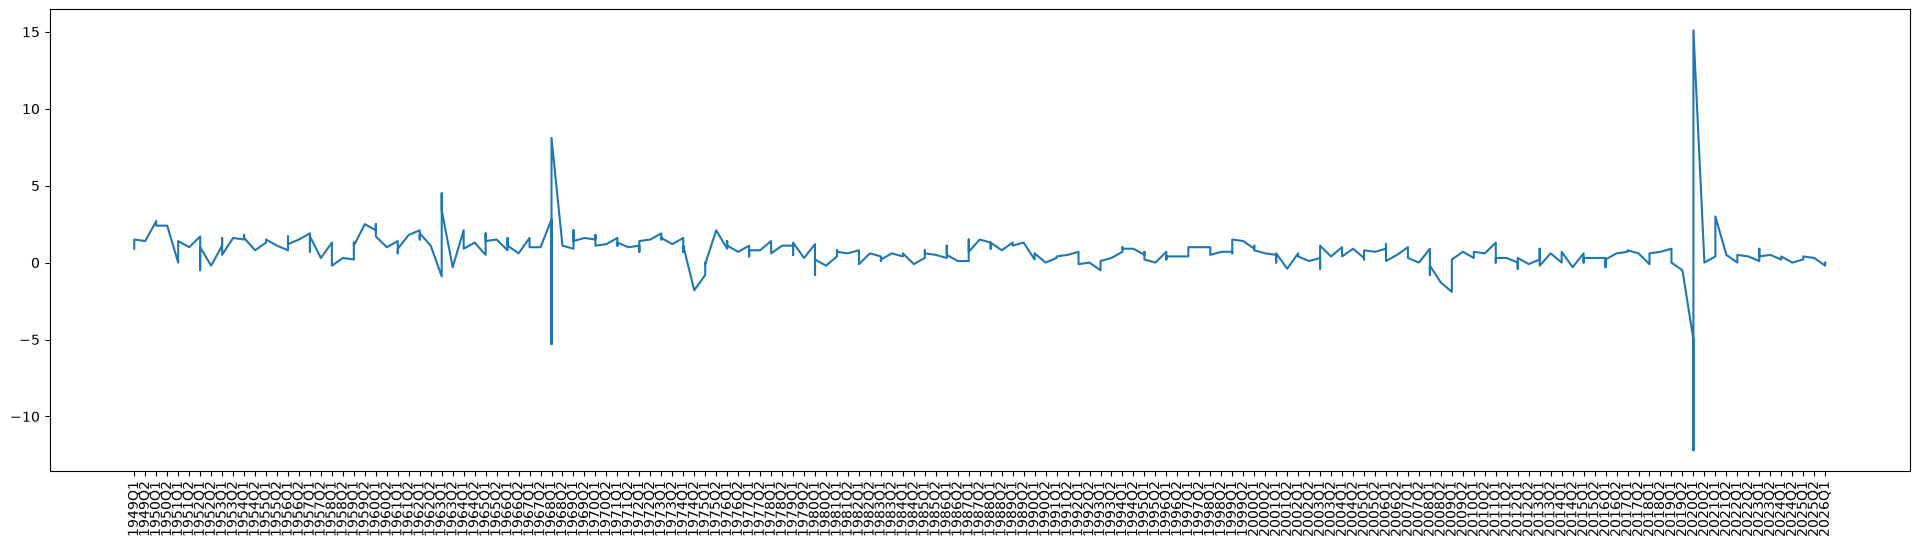

In [47]:
plt.figure(figsize=(24, 6))
plt.plot(dates.astype(str), series)
plt.xticks(rotation=90)
plt.show()

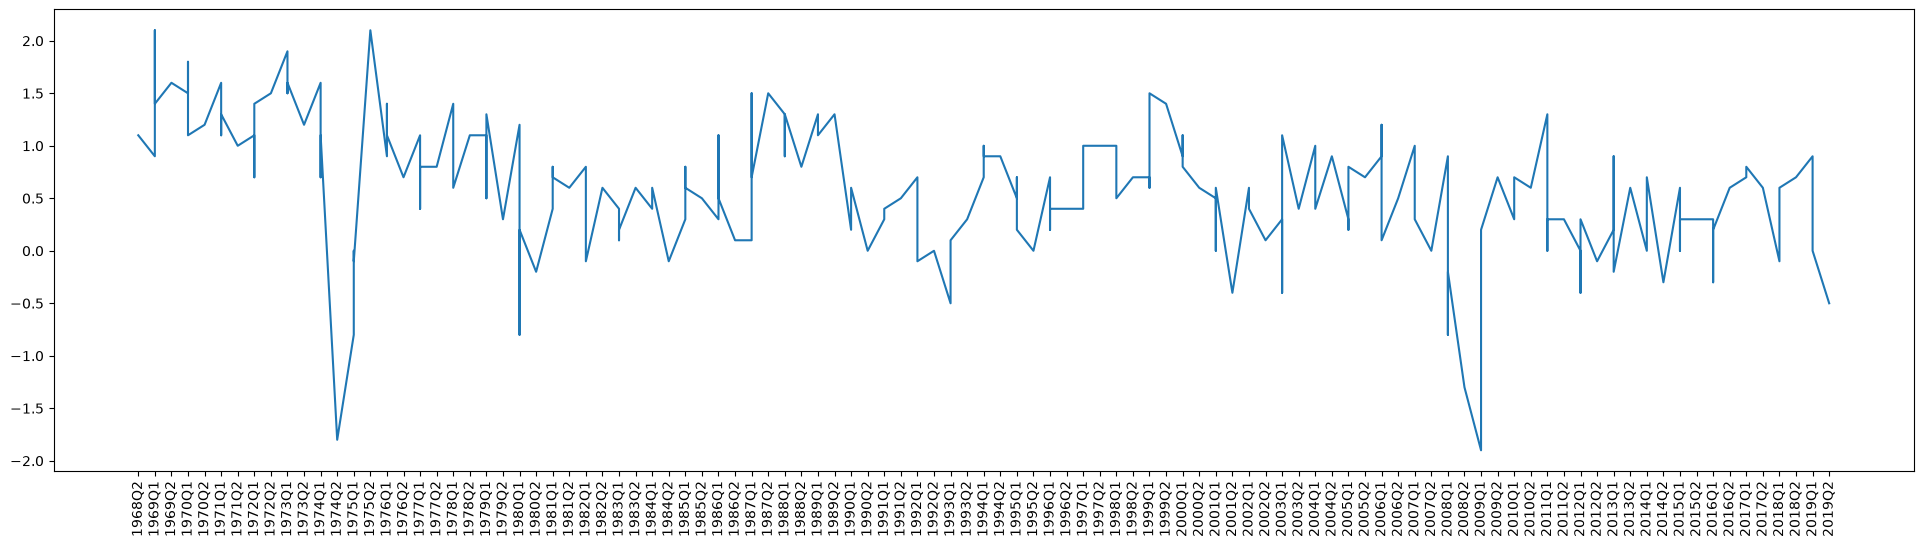

In [51]:
df = df[
    (df["Trimestre"] >= pd.Period("1968Q2")) &
    (df["Trimestre"] <= pd.Period("2019Q4"))
].reset_index(drop=True)

dates = df["Trimestre"]
series = df["Produit intérieur brut (PIB)"]

plt.figure(figsize=(24, 6))
plt.plot(dates.astype(str), series)
plt.xticks(rotation=90)
plt.show()

In [58]:
afc = acf(series, nlags=36)
pafc = pacf(series, nlags=36)

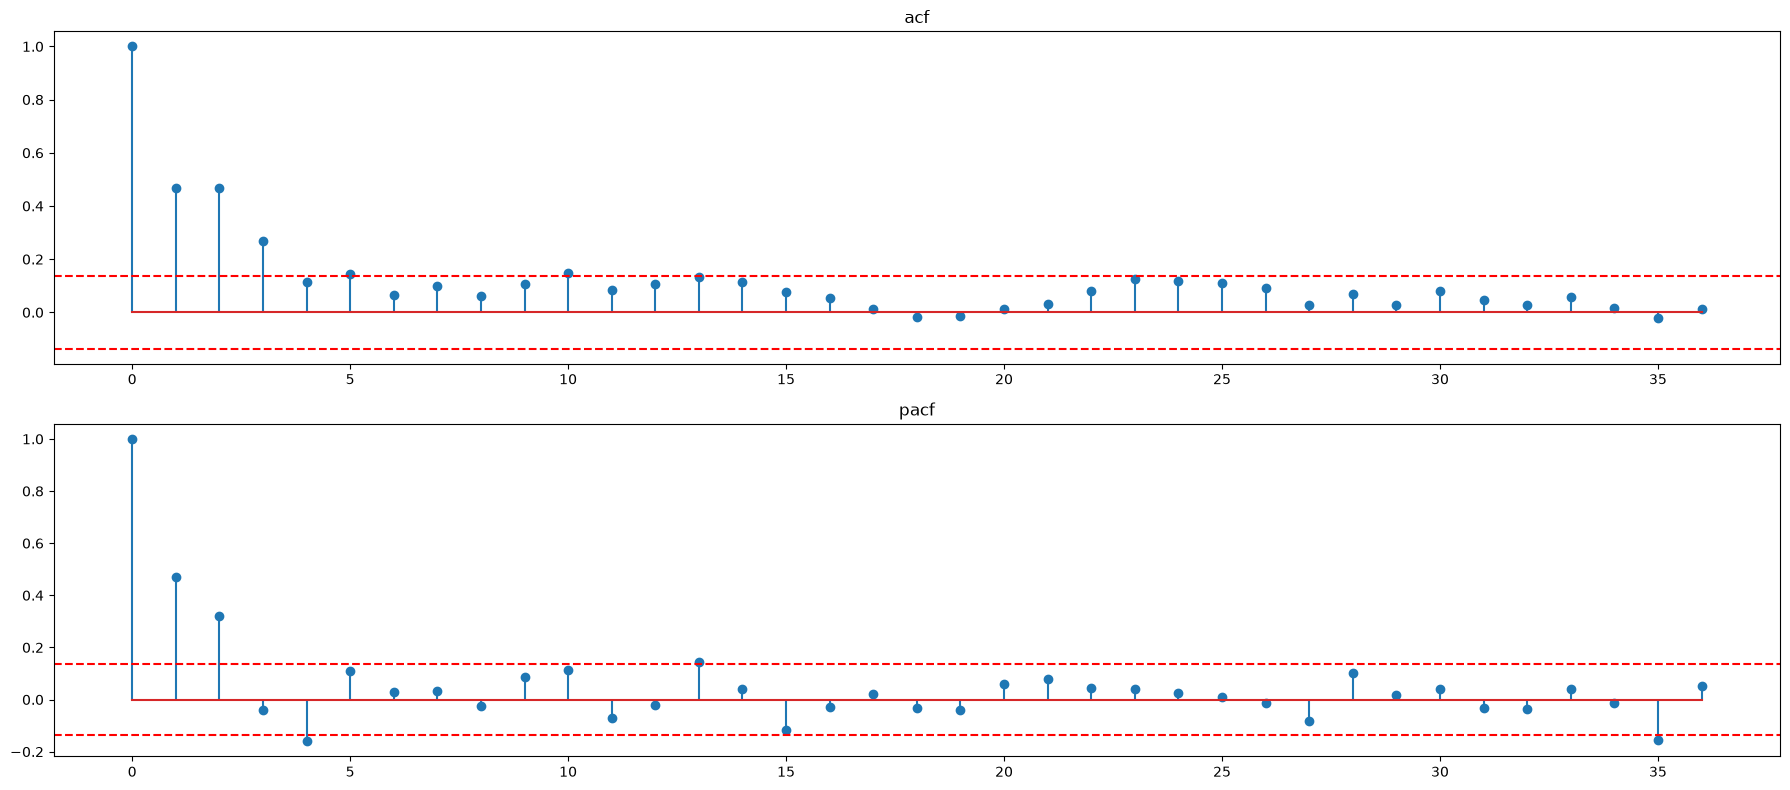

In [63]:
fig, axes = plt.subplots(2, 1, figsize=(18, 8)) 

significance = 1.96 / np.sqrt(len(series))

axes[0].stem(range(37), afc)
axes[0].set_title(f"acf")
axes[1].stem(range(37), pafc)
axes[1].set_title(f"pacf")
axes[0].axhline(significance, color="red", linestyle="--")
axes[0].axhline(-significance, color="red", linestyle="--")
axes[1].axhline(significance, color="red", linestyle="--")
axes[1].axhline(-significance, color="red", linestyle="--")

plt.tight_layout()
plt.show()

                                    SARIMAX Results                                     
Dep. Variable:     Produit intérieur brut (PIB)   No. Observations:                  205
Model:                           ARIMA(2, 0, 3)   Log Likelihood                -146.203
Date:                          Fri, 11 Sep 2026   AIC                            306.407
Time:                                  16:35:10   BIC                            329.668
Sample:                                       0   HQIC                           315.815
                                          - 205                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5719      0.084      6.830      0.000       0.408       0.736
ar.L1         -0.3902      0.328     -1.188      0.

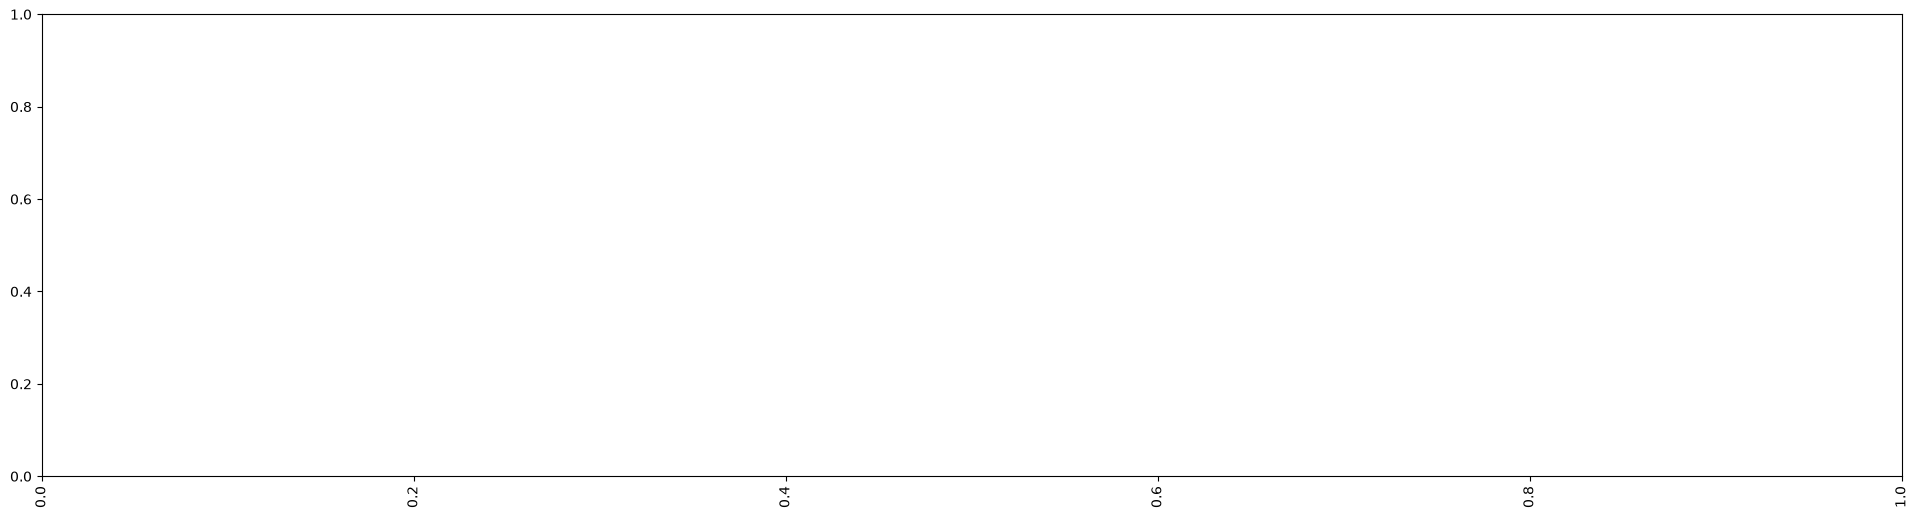

In [69]:
model = ARIMA(series, order=(2, 0, 3))
result = model.fit()

print(result.summary())

plt.figure(figsize=(24, 6))
plt.xticks(rotation=90)
plt.show()